In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist, squareform

from sklearn.metrics import pairwise_distances, silhouette_score, adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

In [25]:
%run LittRuP__import_functions.ipynb

In [26]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()
DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"

In [27]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [28]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [29]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [30]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

**Préliminaires : processus de linkage**

In [31]:
# on compare les thèmes entre eux selon leur présence/absence dans les œuvres :
# Jaccard → adapté aux données binaires 0/1
# average linkage → moins brutal que complete linkage

X_themes = matrix_themes.T.to_numpy().astype(bool)

dist_themes = pdist(
    X_themes,
    metric="jaccard"
)

ZA = linkage(
    dist_themes,
    method="average"
)

ZC = linkage(
    dist_themes,
    method="complete"
)

**Liste des clusters envisagés**

In [32]:
x_max = 20
list_k = list(range(2,x_max))

**Calcul des scores silhouette ('average' + 'complete')**

In [33]:
results = {}
labels_dict = {k: {} for k in list_k}

for linkage_method in ["average", "complete"]:

    scores = []

    for k in list_k:

# la boucle "for" vise à répondre à la question :
# combien de clusters faut-il choisir ? 

        model = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage=linkage_method
        )
        
        clusters = model.fit_predict(squareform(dist_themes))

        labels_dict[k][linkage_method] = clusters

        score = silhouette_score(
            squareform(dist_themes),
            clusters,
            metric="precomputed"
        )

# pour chaque valeur de k, le code calcule un score
# qui mesure la qualité du découpage en k clusters   

        scores.append(score)

    results[linkage_method] = scores

**indice de Rand pour comparaison des méthodes**

In [34]:
ARIs = []

for k in list_k:

# -> résultats du "labels_dict[k][linkage_method]" précédemment créé

    labels_avg = labels_dict[k]["average"]
    labels_com = labels_dict[k]["complete"]

    ari = adjusted_rand_score(
        labels_avg,
        labels_com
    )
    
    ARIs.append(ari)

**Graphiques de clustering**

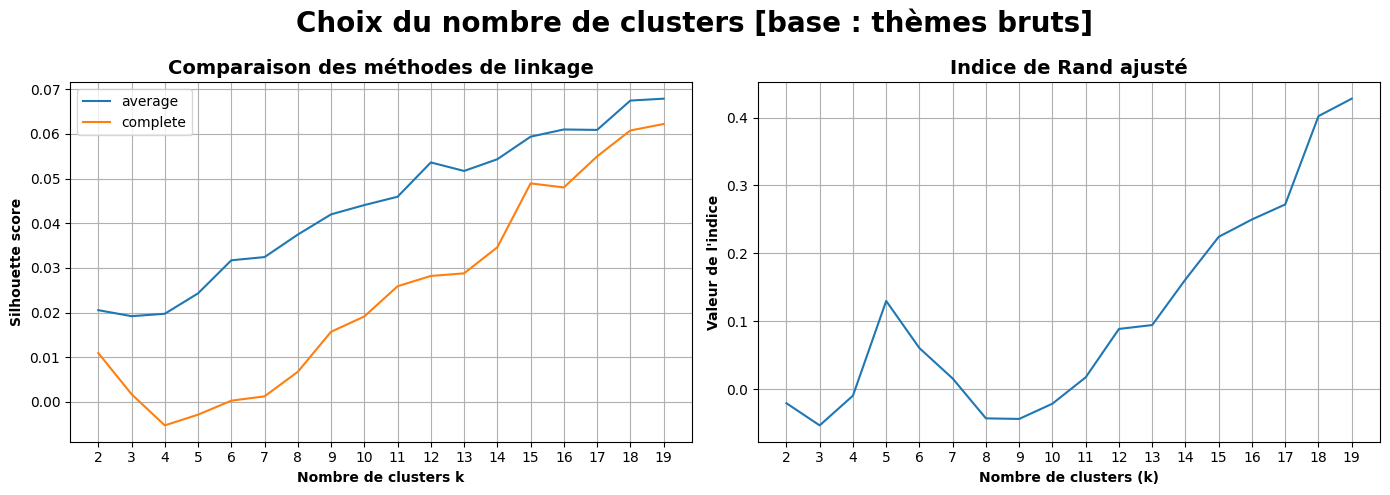

In [35]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# --- Graphique 1 : score de silhouette ---

for linkage_method, scores in results.items():
    axes[0].plot(list_k, scores, label=linkage_method)
    axes[0].set_xlabel("Nombre de clusters k", fontweight="bold")
    axes[0].set_xticks(list_k)
    axes[0].set_ylabel("Silhouette score", fontweight="bold")
    axes[0].set_title("Comparaison des méthodes de linkage", fontsize=14, fontweight="bold")
    axes[0].legend()
    axes[0].grid(True)

# --- Graphique 2 : indice de Rand ---

axes[1].plot(list_k, ARIs)
axes[1].set_title("Indice de Rand ajusté", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Nombre de clusters (k)", fontweight="bold")
axes[1].set_xticks(list_k)
axes[1].set_ylabel("Valeur de l'indice", fontweight="bold")
axes[1].grid(True)

# --- Sur-titre global ---

fig.suptitle(
    "Choix du nombre de clusters [base : thèmes bruts]",
    fontsize=20, 
    fontweight="bold"
)

# Ajustement des espacements (important avec suptitle

fig.tight_layout(rect=[0, 0, 1, 1.0])

fig.savefig(
    IMG_DIR / "thèmes_choix_nombre_clusters.png", 
    dpi=300,
    bbox_inches="tight")

plt.show()